In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [105]:
PROCESSED_DIR = os.path.join("..", "data", "processed")
RAW_DIR = os.path.join("..", "data", "raw")
df1 = pd.read_csv(os.path.join(PROCESSED_DIR, "customer_churn_df_clean.csv"), keep_default_na = False)
# df1 = pd.read_csv(r"C:\Users\Arpita\Desktop\Customer Churn Prediction\data\processed\customer_churn_df_clean.csv", keep_default_na = False)
df2 = pd.read_csv(os.path.join(RAW_DIR, "telecom_zipcode_population.csv"))
# df2 = pd.read_csv(r"C:\Users\Arpita\Desktop\Customer Churn Prediction\data\raw\telecom_zipcode_population.csv")

In [106]:
pd.set_option('display.max_columns', None)

In [107]:
df1.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,None,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.0,0,381.51,974.81,Stayed,,
1,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.0,0,134.60,415.45,Churned,Competitor,Competitor had better devices
2,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.0,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
3,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,None,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.0,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
4,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,9,Offer E,Yes,16.77,No,Yes,Cable,73.0,No,No,No,Yes,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Credit Card,69.4,571.45,0.0,0,150.93,722.38,Stayed,,


In [108]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6923 entries, 0 to 6922
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        6923 non-null   str    
 1   Gender                             6923 non-null   str    
 2   Age                                6923 non-null   int64  
 3   Married                            6923 non-null   str    
 4   Number of Dependents               6923 non-null   int64  
 5   City                               6923 non-null   str    
 6   Zip Code                           6923 non-null   int64  
 7   Latitude                           6923 non-null   float64
 8   Longitude                          6923 non-null   float64
 9   Number of Referrals                6923 non-null   int64  
 10  Tenure in Months                   6923 non-null   int64  
 11  Offer                              6923 non-null   str    
 12  Pho

1. What is overall churn rate? 

Sum of customers with customer_status = 'Churn'/ Total customers who have either churned or stayed
(Here we excluded the 'joined' customers because the wouldn't help clearly in defining churn rate since they have only joined)

In [109]:
no_of_churned_customers = (df1['Customer Status'] == 'Churned').sum()
no_of_stayed_customers = (df1['Customer Status'] == 'Stayed').sum()
churn_rate = round((no_of_churned_customers/(no_of_churned_customers + no_of_stayed_customers) * 100) ,2)
print('Churn rate is:',churn_rate,'%')

Churn rate is: 28.4 %


Industry benchmark for churning rate in a telecom comapny is around 20% (Source: https://growth-onomics.com/churn-rate-benchmarks-by-industry-2025/)
So, the average churn rate is 20% whereas here we found that it is 28.4% which means the churning rate is about 8.4 percentage points more than the average. 


The customer churn rate is 28.40% , which is 8.4 percentage points higher than the industry benchmark. This indicates the company faces significant retention problem.

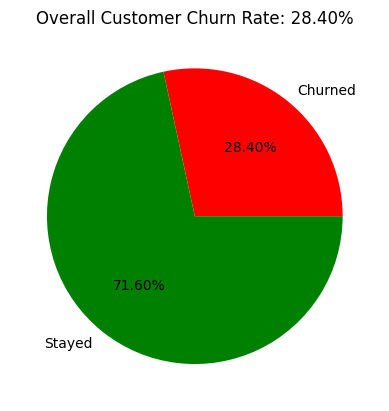

In [110]:
labels = ['Churned', 'Stayed']
sizes = [no_of_churned_customers, no_of_stayed_customers]
plt.pie(sizes, 
    labels = labels, 
    autopct = '%1.2f%%',
    colors = ['red', 'green'])
plt.title('Overall Customer Churn Rate: 28.40%')
plt.show()


2. What are the primary churn reasons and categories?

In [111]:
churned_customers = df1[df1['Customer Status'] == 'Churned']

In [112]:
churn_category_counts = churned_customers['Churn Category'].value_counts(normalize = True)*100
churn_category_counts 

Churn Category
Competitor         45.187602
Dissatisfaction    16.965742
Attitude           16.693855
Price              11.364872
Other               9.787928
Name: proportion, dtype: float64

In [113]:
churn_reason_counts = churned_customers['Churn Reason'].value_counts() 
churn_reason_counts_filter = churned_customers['Churn Reason'].value_counts() >40
churn_reason_counts_bar= churn_reason_counts[churn_reason_counts_filter]

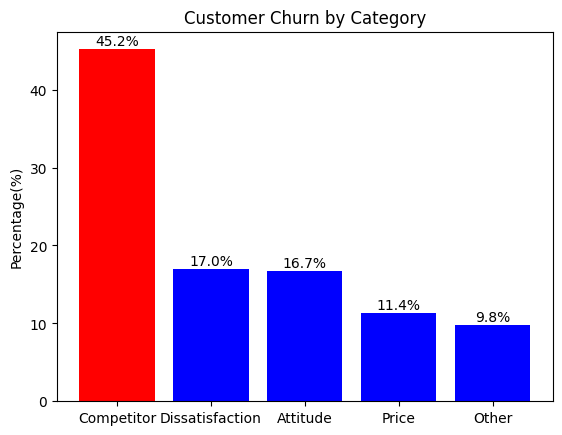

In [114]:
# bar chart for churn category 

bars = plt.bar(churn_category_counts.index, churn_category_counts.values,
    color = ['Red', 'Blue', 'Blue', 'Blue', 'Blue'])
for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    plt.text(
        bar.get_x() + width/2, height + 0.5,
        f'{height:.1f}%',
        ha = 'center'
    )
plt.ylabel('Percentage(%)')
plt.title('Customer Churn by Category')
plt.show()

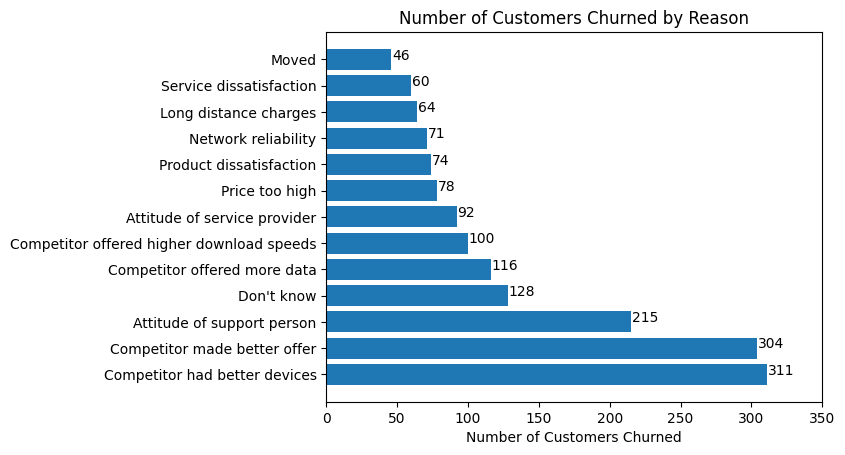

In [115]:
# bar chart for churn reason
bars = plt.barh(
    churn_reason_counts_bar.index, churn_reason_counts_bar.values,
)

for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    plt.text(

        width + 0.5, bar.get_y() + height/2,
        f'{width:.0f}',
        ha = 'left'
    )
plt.xlabel('Number of Customers Churned')
plt.title('Number of Customers Churned by Reason')
plt.xlim(0,350)
plt.show()

The top churn category is competitor, contributing 45.2% category. 
Also, it is seen that price category is 11.4% while attitude of staff is 16.7%. This means customers are leaving more because of how staff treats them than because of what they pay. Therefore, company should invest on customer servicing training.
'Don't know' appears as a churn reason with 128 customers. That's the 4th highest reason. These 128 represent unactionable churn.

The overall churn rate is 28.4%, higher than industry benchmark and the biggest reason of customers' churning is competitor, they made better offer, had better devices and offered more. 



The largest churn category is 'competitor', accounting for 45.2% of all churned customers. 
This suggests that competitive nature is the primary driver of customer attrition.

Customer service-related issues appear to have a greater impact than pricing.
the 'attitude' category accounts for 16.7% ofchurn compared to11.4% for 'price'.
This indicates that customer experience and staff interactions may be contributing more to churn than pricing concerns.

The churn reason 'Don't know' was reported by 128 customers making it the fourth most common reason.
This represents a significant amount of unclassfied churnad ma indicate limitations in the customer exit survey process.

Competitor related reasons:
- Better devices: 311 customers
- Better offers: 304 customers
- More data: 116 customers
- Higher download speeds: 100 customers
This indicates that competitors are outperforming the company in bothproduct offerings and percieved value.

3. Monthly revenue loss due to churn

In [116]:
churned_monthly_revenue = df1[df1['Customer Status'] == 'Churned']['Monthly Charge'].sum()
total_monthly_revenue = df1[df1['Customer Status'] != 'Joined']['Monthly Charge'].sum()
monthly_revenue_loss_per = round(churned_monthly_revenue/total_monthly_revenue *100, 2)
print(f"The monthly revenue loss due to churning is ${churned_monthly_revenue:,.2f}, which means {monthly_revenue_loss_per:.2f}%")
print(f"The annual revenue loss due to churning is ${churned_monthly_revenue*12:,.2f}.")


The monthly revenue loss due to churning is $137,231.65, which means 31.98%
The annual revenue loss due to churning is $1,646,779.80.


Churned customers account for $137,231.65 in monthly recurring revenue, representing 31.98% of the company's total monthly revenue.

Churned customers contribute a larger share of reveue (31.98%) than their share of the customer base(28.4%), suggesting that higher value customers are leaving at a slightly higher rate. This means the churn problem is more financially damaging than the customer count alone, i.e., customers who left were spending more money than the average customer. 

Based on current monthly revenue levels, churn represents an estimated annualized revenue loss of approximately $1.65 millon.

Note: The currency is not mentioned in the dataset. Assumed to be USD($).

4. Does age group affect churn?

Taking age groups in range of 10: 18-24, 25-34... and 75-80
And doing the comaprision on the basis of percentage, because on doing so, it will be combined result of customers who stayed and who churned (excluding joined customers). Also the age grp like 18-24 is smaller comparatively, and we go for number of counts, then it would be misleading.

In [117]:
age_grps = pd.cut(df1['Age'], bins = [18, 25,35,45,55,65,75,80], labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-80'], right = False, include_lowest= True)
df1["Age Groups"] = age_grps

churned_or_stayed_df = df1[df1['Customer Status'] != 'Joined']

churned_or_stayed_df['Churned'] = (churned_or_stayed_df['Customer Status'] == 'Churned').astype(int)

churn_rate_age_grps = round(churned_or_stayed_df.groupby('Age Groups')['Churned'].mean() * 100, 2)
churn_rate_age_grps

# churned_or_stayed_df.groupby('Age Groups')['Customer Status'].mean()
# churned_or_stayed_df

Age Groups
18-24    22.07
25-34    26.05
35-44    26.09
45-54    26.15
55-64    25.62
65-74    42.79
75-80    42.52
Name: Churned, dtype: float64

In [118]:
# no of customers in each age group
df1['Age Groups'].value_counts().sort_index()

Age Groups
18-24     764
25-34    1235
35-44    1293
45-54    1261
55-64    1249
65-74     709
75-80     347
Name: count, dtype: int64

In [119]:
# now checking for articularly for customers having age between 65 to 80

# among all customers, what is churning rate of customers in this age group
churned_or_stayed_df['Churned Senior'] = ((churned_or_stayed_df['Customer Status'] == 'Churned') & (churned_or_stayed_df['Age Groups'].isin(['65-74', '75-80']))).astype(int)
print(round(churned_or_stayed_df['Churned Senior'].mean() * 100, 2))

# Checking category of churning for this age group
churned_or_stayed_df[churned_or_stayed_df['Churned Senior'] == 1]['Churn Reason'].value_counts(normalize=True)*100

6.78


Churn Reason
Competitor made better offer                 18.678815
Competitor had better devices                18.223235
Attitude of support person                   13.439636
Price too high                                5.922551
Don't know                                    5.694761
Attitude of service provider                  5.466970
Competitor offered more data                  5.239180
Product dissatisfaction                       4.555809
Network reliability                           3.872437
Limited range of services                     3.189066
Service dissatisfaction                       2.961276
Extra data charges                            2.505695
Competitor offered higher download speeds     2.277904
Long distance charges                         2.050114
Poor expertise of online support              2.050114
Lack of affordable download/upload speed      1.594533
Moved                                         1.594533
Deceased                                      0.4555

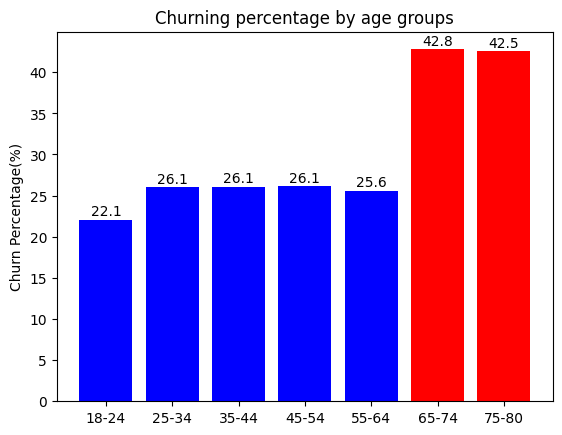

In [120]:
bars = plt.bar(churn_rate_age_grps.index, churn_rate_age_grps.values, color = ['Blue', 'Blue', 'Blue', 'Blue', 'Blue', 'Red', 'Red'])
plt.title('Churning percentage by age groups')
plt.ylabel('Churn Percentage(%)')
for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    plt.text(bar.get_x() + width/2, height + 0.5, f'{height:.1f}', ha= 'center')

The churn rate for customers having age between 18-64 is around between 22-26% and then there is spike seen in churning rate in the age group between 65-80 with around 43% churning rate.
The churning reason of senior customers is driven significantly due to two reasons, the 'competitor' being the biggest reason. And the next big reason is 'attitude of support person'.
Senior customers rely more on support staff as they are less likely to use self-service technology, making staff attitude a disproportionately significant churn factor for this segment.
The company should introduce senior-targeted retention plans with competitive pricing and dedicated support staff trained specifically to assist less tech-savvy customers.


5. Which cities and zip codes have the highest churn rate?

In [121]:
print(f"Unique cities: {df1['City'].nunique()}")
print(f"Unique zip codes: {df1['Zip Code'].nunique()}")

Unique cities: 1106
Unique zip codes: 1626


In [122]:
df1.groupby('City')['City'].value_counts().sort_values(ascending= False)

City
Los Angeles      287
San Diego        278
San Jose         112
Sacramento       107
San Francisco    103
                ... 
Johannesburg       2
Jolon              2
Holtville          2
Jacumba            2
Eldridge           2
Name: count, Length: 1106, dtype: int64

In [123]:
churn_rate_city = churned_or_stayed_df.groupby('City')['Churned'].agg(
    customer_churn_or_stay_by_city = 'count',
    churn_rate_by_city = lambda x: round((x.mean()*100),2)
)
churn_rate_city

,customer_churn_or_stay_by_city,churn_rate_by_city
City,,
Acampo,4,75.00
Acton,4,0.00
Adelanto,5,20.00
Adin,4,50.00
Agoura Hills,3,66.67
...,...,...
Yreka,4,0.00
Yuba City,8,25.00
Yucaipa,4,25.00


In [124]:
# I chose 30 as a minimum because at this size, no single customer's churn decision can swing the rate by more than ~3 percentage points, making the rate a more stable signal of city-level behavior rather than noise from small samples.
churn_rate_city[churn_rate_city['customer_churn_or_stay_by_city'] >=30].sort_values(by = 'churn_rate_by_city', ascending = False)

,customer_churn_or_stay_by_city,churn_rate_by_city
City,,
San Diego,271,66.42
Fallbrook,40,65.00
Temecula,36,61.11
Glendale,31,38.71
Escondido,48,33.33
San Francisco,96,32.29
Berkeley,30,30.00
Stockton,41,29.27
Los Angeles,269,28.62


From th top 5 cities, these 4: San Diego, Fallbrook, Temecula, and Escondido, are all in the same Southern Califonia region. These cities are geographically clustered. 

In [125]:

churned_or_stayed_df[churned_or_stayed_df['City'].isin(['San Diego', 'Fallbrook', 'Temecula', 'Escondido'])]['Churn Category'].value_counts(normalize= True)*100

Churn Category
Competitor         51.139241
                   38.227848
Other               4.810127
Attitude            2.784810
Dissatisfaction     2.531646
Price               0.506329
Name: proportion, dtype: float64

This suggests that in this Southern California region, 82.8% category for churning falls under 'Competitor'. The overall benchmark from 'Competitor' was 45.2% of churn category company-wide, which means in this region, 'Competitor' is 37.6 percentage points higher than benchmark.

In [126]:
# zip code analysis
df1.groupby('Zip Code')['Zip Code'].value_counts().sort_values(ascending= False)

Zip Code
92028    42
92027    38
92122    35
92117    32
92126    32
         ..
93528     2
91934     2
92105     2
96150     2
93711     1
Name: count, Length: 1626, dtype: int64

In [127]:
churn_rate_zip = churned_or_stayed_df.groupby('Zip Code')['Churned'].agg(
    customer_churn_or_stay_by_zip = 'count',
    churn_rate_by_zip = lambda x: round((x.mean()*100),2)
)
churn_rate_zip

,customer_churn_or_stay_by_zip,churn_rate_by_zip
Zip Code,,
90001,3,33.33
90002,3,0.00
90003,3,33.33
90004,5,40.00
90005,4,50.00
...,...,...
96143,4,25.00
96145,3,0.00
96146,2,0.00


In [128]:
churn_rate_zip[churn_rate_zip['customer_churn_or_stay_by_zip'] >=10].sort_values(by = 'churn_rate_by_zip', ascending = False)

,customer_churn_or_stay_by_zip,churn_rate_by_zip
Zip Code,,
92122,33,96.97
92130,21,95.24
92129,16,93.75
92109,27,88.89
92126,32,87.50
92117,32,87.50
92121,18,83.33
92028,40,65.00
92592,28,64.29


In [129]:
df1[df1['City'] == 'San Diego']['Zip Code'].sort_values()

685     92101
4807    92101
3593    92101
1293    92101
3235    92102
        ...  
1128    92139
4688    92154
5798    92154
944     92154
5066    92154
Name: Zip Code, Length: 278, dtype: int64

The zip codes having prefix 921xx are having the maximum churn rate by zip code, ad all these zip codes belong to city San Diego

In [130]:
# bringing population table in, penetration and all that
df_join = pd.merge(churn_rate_zip[churn_rate_zip['customer_churn_or_stay_by_zip'] >=10], df2, on='Zip Code', how='inner')
df_join['penetration(%)'] = (df_join['customer_churn_or_stay_by_zip']/ df_join['Population'])*100
df_join.sort_values(by = 'penetration(%)', ascending= False)

,Zip Code,customer_churn_or_stay_by_zip,churn_rate_by_zip,Population,penetration(%)
4,92121,18,83.33,4258,0.422734
1,92028,40,65.00,42239,0.094699
5,92122,33,96.97,34902,0.094550
8,92130,21,95.24,28201,0.074465
0,92027,35,42.86,48690,0.071883
3,92117,32,87.50,51213,0.062484
9,92592,28,64.29,46171,0.060644
2,92109,27,88.89,46086,0.058586
6,92126,32,87.50,74232,0.043108
7,92129,16,93.75,47224,0.033881


In [131]:
# joined customers analysis

# df1['joined_customers'] = (df1['Customer Status']=='Joined').value_counts().astype(int)
# no_of_customers_joined_by_city = (df1['Customer Status'] == 'Joined').groupby('City')['joined_customers'].sum()
# no_of_churned_customers

# df1.drop(columns=['joined_customers'])

df1['Customer Status'].value_counts(normalize=True)*100

Customer Status
Stayed     66.965189
Churned    26.563628
Joined      6.471183
Name: proportion, dtype: float64

In [132]:
df1[df1['City']=='San Diego']['Customer Status'].value_counts()

Customer Status
Churned    180
Stayed      91
Joined       7
Name: count, dtype: int64

In [133]:
df1[df1['City']=='San Diego']['Customer Status'].value_counts(normalize=True)*100

Customer Status
Churned    64.748201
Stayed     32.733813
Joined      2.517986
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Cities with Highest Churn Rate')

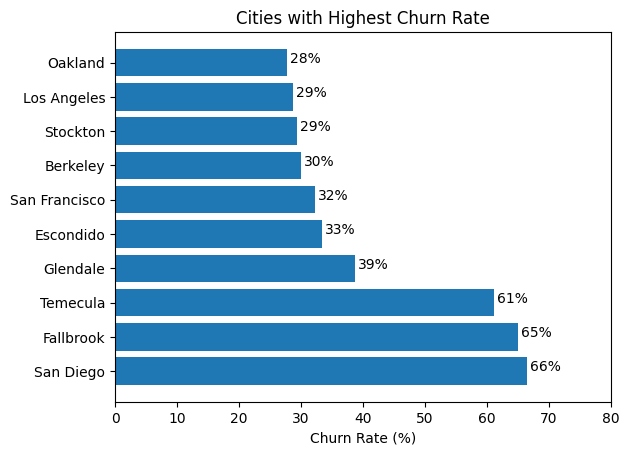

In [134]:
top_cities_churn = churn_rate_city[churn_rate_city['customer_churn_or_stay_by_city'] >=30].sort_values(by ='churn_rate_by_city', ascending = False).head(10)
bars = plt.barh(top_cities_churn.index, top_cities_churn['churn_rate_by_city'].values)
for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    plt.text(

        width + 0.5, bar.get_y() + height/2,
        f'{width:.0f}%',
        ha = 'left'
    )
plt.xlabel('Churn Rate (%)')
plt.xlim(0,80)
plt.title('Cities with Highest Churn Rate')

In [135]:
#plotting for overall vs san diego
comparision_san_diego = {
    "Churned": [
        ( ((df1['Customer Status']=='Churned').astype(int)).sum() ) / ( df1['Customer Status'].value_counts().sum() )*100 , 
        ( (((df1['Customer Status']=='Churned') & (df1['City'] == 'San Diego')).astype(int)).sum() ) / (df1['City'] == 'San Diego').astype(int).sum()*100
        ],
    "Stayed":[
        ( ((df1['Customer Status']=='Stayed').astype(int)).sum() ) / ( df1['Customer Status'].value_counts().sum() )*100 , 
        ( ((df1['Customer Status']=='Stayed') & (df1['City'] == 'San Diego')).astype(int)).sum() / (df1['City'] == 'San Diego').astype(int).sum()*100
        ],
    "Joined": [
        ( ((df1['Customer Status']=='Joined').astype(int)).sum() ) / ( df1['Customer Status'].value_counts().sum() )*100, 
        (((df1['Customer Status']=='Joined') & (df1['City'] == 'San Diego')).astype(int)).sum() / (df1['City'] == 'San Diego').astype(int).sum()*100
        ]
}
comparision_san_diego_df = pd.DataFrame(comparision_san_diego, index = ['Overall', 'San Diego']).round(2)
comparision_san_diego_df = comparision_san_diego_df.T
comparision_san_diego_df

,Overall,San Diego
Churned,26.56,64.75
Stayed,66.97,32.73
Joined,6.47,2.52


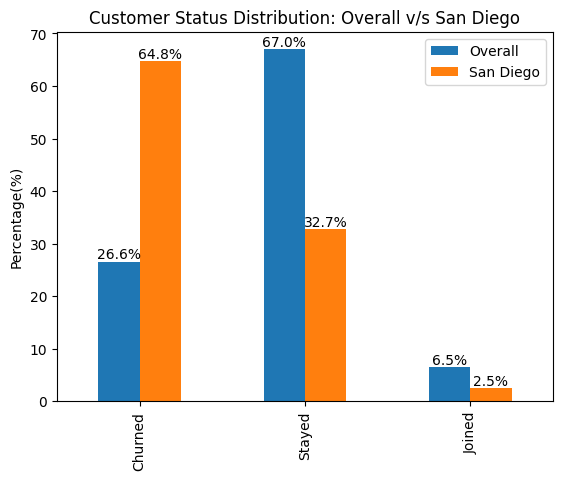

In [136]:
ax = comparision_san_diego_df.plot(kind = 'bar')
plt.title('Customer Status Distribution: Overall v/s San Diego')
plt.ylabel('Percentage(%)')
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')

- The cities having maximum churn rate are: San Diego, Fallbrook, Temecula, Glendale, Escondido, San Francisco, Berkeley, Stockton, Los Angeles and Oakland, given the total number of churned and stayed customers per city is more than or equal to 30. 

- On finding churn rate grouped by city, it is seen that out of top 5 cities, these 4: San Diego, Fallbrook, Temecula, and Escondido, are all in the same Southern Califonia region. These cities are geographically clustered; given the total number of churned and stayed customers per city is more than or equal to 30. 
Taking 30 as a minimum because at this size, no single customer's churn decision can swing the rate by more than ~3 percentage points, making the rate a more stable signal of city-level behavior rather than noise from small samples. 

- Also, checking for customer churning category in these 4 cities suggests that in this Southern California region, 82.8% category for churning falls under 'Competitor'. The overall benchmark from 'Competitor' was 45.2% of churn category company-wide, which means in this region, 'Competitor' is 37.6 percentage points higher than benchmark.

- Doing the similar analysis on churning by zip codes, it is found that the top 7 zip codes having maximum having churn rate (83-97%) have prefix 921xx, and all these zip codes belong to city San Diego, given the total number of churned and stayed customers per zip code is more than or equal to 10. 

- On comparision of overall customer status and San Diego customer status, it is seen churning percentage of San Diego is 64.8% which is 38.2 percentage points higher than overall churning percentage. The stayed percentage of San Diego is 32.7%, which is 34.3 percentage points less than that of overall stayed percentage and the joined percentage of San Diego is 2.5%, which is 4 percentage points lower than overall joined percentage. This joined information is based on just 7 joined customers in San Diego which is directionally suggestive but not statistically conclusive given the small count

- To assess the company's presence in the highest-churn zip codes, customer counts were compared against local population. Customer penetration across these zip codes ranges from approximately 0.03% to 0.42% of the local population, indicating that the company has a very limited market in these areas. The combination of very low penetration and very high churn rates(83%-97%) suggests that the company is not only struggling to retain customers in these zip codes but also failed to establish customer base in the first place.

- The analysis identifies San Diego and nearby Southern California cities as a clear churn hotspot. Churning in this region is higher than the company average, which is driven by competitor-related reasons. However, these locations also exhibit low market penetration, indicating that company has only a limited presence in the region. This data suggests difficulty in both acquiring and retaining customers in this market. Consequently the key strategic question is not simply how to improve retention in San Diego, but whether the company should continue competing in this market under its current approach and if so, what chnages in competitive strategy, pricing, service quality or customer aquisition are required.


6. Do customers with shorter tenure churn more?

In [137]:
#creating tenure months groups 
tenure_grps_in_months = pd.cut(df1['Tenure in Months'], bins = [0, 7, 13, 25, 49, 72], labels=['0-6', '7-12', '13-24', '25-48', '49-72'], right = False, include_lowest= True)
df1["Tenure Groups in Months"] = tenure_grps_in_months
df1["Tenure Groups in Months"].value_counts()
churned_or_stayed_df["Tenure Groups in Months"] = tenure_grps_in_months

In [138]:
churn_rate_tenure_groups = round(churned_or_stayed_df.groupby('Tenure Groups in Months')['Churned'].mean()*100,2)
churn_rate_tenure_groups

Tenure Groups in Months
0-6      77.01
7-12     35.71
13-24    28.67
25-48    20.48
49-72    11.20
Name: Churned, dtype: float64

In [139]:
# for analysing for customers having early tenure months
# churned_or_stayed_df.drop(columns = ['Churned Early Tenure'], inplace = True)
churned_or_stayed_df['Churned Early Tenure'] = ((churned_or_stayed_df['Customer Status']== 'Churned') & (churned_or_stayed_df['Tenure Groups in Months'].isin(['0-6', '7-12']))).astype(int)
churned_or_stayed_df[churned_or_stayed_df['Churned Early Tenure']==1]['Churn Reason'].value_counts(normalize=True)*100 

Churn Reason
Competitor made better offer                 18.485742
Competitor had better devices                17.797443
Attitude of support person                   11.799410
Don't know                                    6.096362
Attitude of service provider                  5.506391
Competitor offered more data                  5.113078
Competitor offered higher download speeds     5.014749
Network reliability                           4.228122
Price too high                                4.031465
Long distance charges                         3.933137
Product dissatisfaction                       3.244838
Service dissatisfaction                       2.654867
Moved                                         2.359882
Limited range of services                     2.359882
Extra data charges                            1.769912
Poor expertise of online support              1.573255
Lack of affordable download/upload speed      1.474926
Lack of self-service on Website               1.4749

In [140]:
churned_or_stayed_df[churned_or_stayed_df['Churned Early Tenure']==1]['Churn Category'].value_counts(normalize=True)*100 

Churn Category
Competitor         46.411013
Attitude           17.305801
Dissatisfaction    16.224189
Price              11.209440
Other               8.849558
Name: proportion, dtype: float64

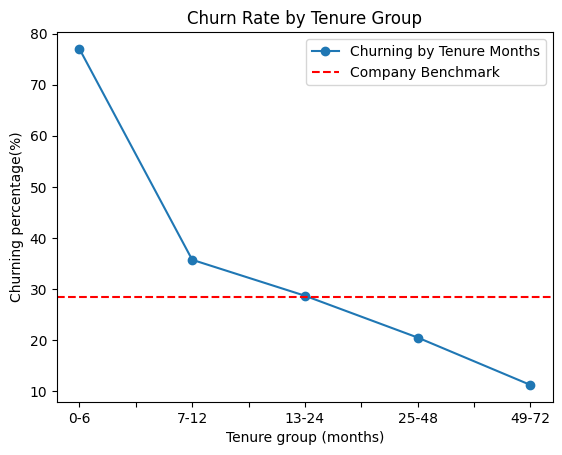

In [141]:
churn_rate_tenure_groups.plot(kind = 'line', marker = 'o', label = 'Churning by Tenure Months')
plt.xlabel('Tenure group (months)')
plt.ylabel('Churning percentage(%)')
plt.title('Churn Rate by Tenure Group')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.legend()

- Customers with shorter tenure exhibit significantly higher churn rates compared to long-tenured cutsomers. The churn rate is highest among customers with 0-6 months of tenure (77.01%) and drops sharply to 35.71% for cutomers with 7-12 months of tenure, a drop of of 41.3 percentage points in a single 6-month step. After the first year, churn continues to decline, but at a much slower rate, reaching only 11.20% for customers with 49-72 months of tenure. 
- Notably, the churn rate falls below the company-wide average of approximately 28.4% after the 13-24 mont tenure groups. This indicates that the customers who remain beyond approximately two years tend to exhibit churn behavior that is at or below the overall company average.
- For early tenure months, 0-12, the competitor related factors account for nearly half(46.41%) of all early tenure churn. Interestingly, dissatisfaction-relaed reasons were less prevalent than competitor-related reasons among these customers. This suggests that early churn may not primarily result from poor service quality or onboardi failures. Instead, the company may be acquiring  substantial number of highly price-sensitive or promotional-driven customers who are willing to switch providers whenever a more attractive offer becomes available.
- These findings imply that reducing early churn may require not only improving retention programs but also reassessing customer acquisition strategies.

7. Does offer type affect churn? Do customers with no offer churn more?

In [142]:
churn_rate_offer = churned_or_stayed_df.groupby('Offer')['Churned'].agg(
    customer_churn_or_stay_by_offer = 'count',
    churn_rate_by_offer = lambda x: round((x.mean()*100),2)
)
churn_rate_offer =churn_rate_offer.sort_values(by = 'churn_rate_by_offer', ascending = False)
churn_rate_offer

,customer_churn_or_stay_by_offer,churn_rate_by_offer
Offer,,
Offer E,617,67.91
None,3526,29.27
Offer D,593,26.64
Offer C,411,22.87
Offer B,815,12.39
Offer A,513,6.82


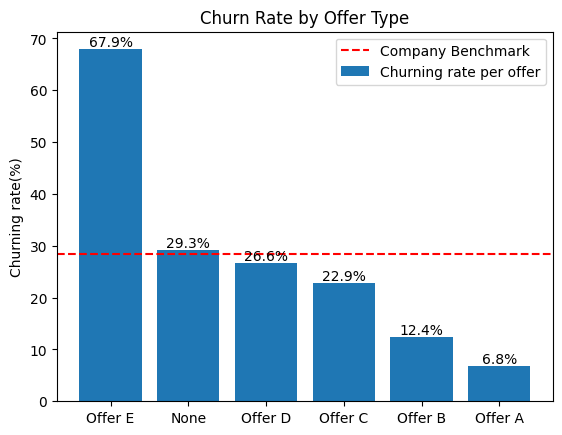

In [143]:
bars = plt.bar(churn_rate_offer.index, churn_rate_offer['churn_rate_by_offer'], label ='Churning rate per offer')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.legend()
plt.title('Churn Rate by Offer Type')
plt.ylabel('Churning rate(%)')
for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    plt.text(
        bar.get_x() + width/2, height+0.5 ,
        f'{height:.1f}%', ha= 'center'
    )


- Offer E's extremely high churn rate 67.91%, which is 39.51 percentage points above the company-wide benchmark, suggests it may be associated with low-quality customer acquisition. Rather than improving retention, the offer appears to attract highly-sensitive customers who are more likely to switch providers once promotional benefits expire or competitors provide better deals. This finding supports the earlier observation that competitor-related factors are a major driver of early churn.
- Customers receiving no offer churn at a rate (29.27%) very close to the overall company average(28.4%). This suggests that merely providing promotional offers is not sufficient to reduce churn. the effectiveness of customer retention initiatives appears to dpeend heavily on the type of offer rather than the presence of an offer itself.
- Offer A exhibits the lowest churn rate (6.82%), significantly below both the company average (21.58 percentage pointsbelow benchmark) and all other offer categories. This suggests that Offer A may represent a retention-focused strategy such as long-term contracts, loyalty incentives, bundled services, or premium customer benefits. Such offers likely strengthen customer commitment and reduce the likelihood of switching to competitors.
- These findings highlight that offer quality and customer targeting are more important than offering promotions indisciminately. Speifically the company should investigate what structural features of Offer A drive its low churn rate, such as contract lock-in and loyalty incnentives and consider redesigning Offer E or restricting it to customers segments with stronger lon-term retention potential. 

8. Does phone service or internet type affect churn? 

In [144]:
churn_rate_phone_service = churned_or_stayed_df.groupby('Phone Service')['Churned'].agg(
    customer_churn_or_stay_by_phone_service = 'count',
    churn_rate_by_phone_service = lambda x: round((x.mean()*100),2)
)
churn_rate_phone_service = churn_rate_phone_service.sort_values(by = 'churn_rate_by_phone_service', ascending = False)
churn_rate_phone_service

,customer_churn_or_stay_by_phone_service,churn_rate_by_phone_service
Phone Service,,
Yes,5842,28.64
No,633,26.22


In [145]:
churn_rate_internet_type = churned_or_stayed_df.groupby('Internet Type')['Churned'].agg(
    customer_churn_or_stay_by_internet_type = 'count',
    churn_rate_by_internet_type = lambda x: round(x.mean()*100 ,2)
)
churn_rate_internet_type = churn_rate_internet_type.sort_values(by = 'churn_rate_by_internet_type', ascending = False)
churn_rate_internet_type

,customer_churn_or_stay_by_internet_type,churn_rate_by_internet_type
Internet Type,,
Fiber Optic,2888,42.21
Cable,762,27.43
DSL,1505,20.00
None,1320,8.33


In [146]:
churned_or_stayed_df[churned_or_stayed_df['Churned']==1].groupby('Internet Type')['Churn Reason'].value_counts(normalize= True)*100

Internet Type  Churn Reason                             
Cable          Competitor had better devices                20.095694
               Competitor made better offer                 14.354067
               Attitude of support person                    9.569378
               Competitor offered higher download speeds     9.090909
               Don't know                                    7.655502
                                                              ...    
None           Attitude of service provider                  4.545455
               Service dissatisfaction                       3.636364
               Limited range of services                     2.727273
               Moved                                         2.727273
               Poor expertise of phone support               0.909091
Name: proportion, Length: 68, dtype: float64

In [147]:
churned_or_stayed_df[churned_or_stayed_df['Churned']==1].groupby('Internet Type')['Churn Category'].value_counts(normalize= True)*100

Internet Type  Churn Category 
Cable          Competitor         50.239234
               Dissatisfaction    18.181818
               Attitude           14.354067
               Other              10.526316
               Price               6.698565
DSL            Competitor         41.196013
               Dissatisfaction    21.594684
               Attitude           13.621262
               Other              12.624585
               Price              10.963455
Fiber Optic    Competitor         47.579984
               Dissatisfaction    16.488925
               Attitude           16.078753
               Price              10.254307
               Other               9.598031
None           Attitude           36.363636
               Price              33.636364
               Competitor         20.000000
               Dissatisfaction     7.272727
               Other               2.727273
Name: proportion, dtype: float64

In [148]:
churned_or_stayed_df[(churned_or_stayed_df['Churned']==1) & (churned_or_stayed_df['Internet Type']=='Fiber Optic')].groupby('Internet Type')['Churn Reason'].value_counts(normalize= True)*100

Internet Type  Churn Reason                             
Fiber Optic    Competitor had better devices                17.801477
               Competitor made better offer                 17.637408
               Attitude of support person                   10.746514
               Competitor offered more data                  7.054963
               Don't know                                    6.726825
               Attitude of service provider                  5.332240
               Competitor offered higher download speeds     5.086136
               Price too high                                4.347826
               Product dissatisfaction                       4.183757
               Network reliability                           3.691550
               Service dissatisfaction                       3.363413
               Moved                                         2.543068
               Extra data charges                            2.214930
               Long distance char

In [149]:
churned_or_stayed_df.groupby('Internet Type')['Age'].mean()
churned_or_stayed_df.groupby('Internet Type')['Age'].median()

Internet Type
Cable          44.0
DSL            45.0
Fiber Optic    50.0
None           43.0
Name: Age, dtype: float64

In [150]:
churned_or_stayed_df.groupby('Internet Type')['Tenure in Months'].mean()
churned_or_stayed_df.groupby('Internet Type')['Tenure in Months'].median()

Internet Type
Cable          32.5
DSL            33.0
Fiber Optic    32.0
None           32.0
Name: Tenure in Months, dtype: float64

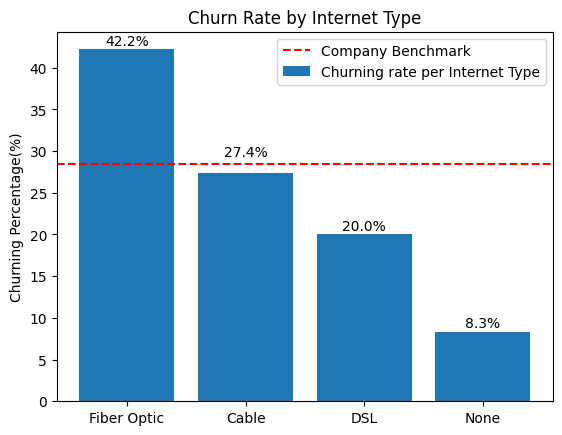

In [151]:
bars = plt.bar(churn_rate_internet_type.index, churn_rate_internet_type['churn_rate_by_internet_type'], label = 'Churning rate per Internet Type')
plt.title('Churn Rate by Internet Type')
plt.ylabel('Churning Percentage(%)')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
for bar in bars:
    width = bar.get_width()
    height = bar.get_height()
    offset = 0.5
    if height == 27.43:
        offset = 2
    plt.text(
        bar.get_x() + width/2, height + offset,
        f'{height:.1f}%', ha= 'center'
    )
plt.legend()


- Customers with and without phone service churn at nearly identical rates with a difference of 2.42 percentage points, suggesting phone service availability is not a major driverof churn. 
- Fiber Optic customers churn at 42.2%, more than double the churn rate of DSL customers (20.0%) and over five times than that of customers without internet service (8.3%), making Fiber Optic customers the highest-risk segment. 
- Nearly half of all Fiber churners leave because of competitors. This is interesting because Fiber is generally the premium internet technology. If customers are still leaving, it suggests the issue is not the technology itself. Customers on Fiber Optic plans are not only having high churning rate (42.2%) but also represent the largest number of churned customers (2,988) making this segment the most significant contributor to overall customer churn.
- If Fiber Optic customers are leaving, it suggests the issue is not the technology itself. They are disproportionately attracted by competitors, suggesting that competitors are offering more attractive packages, promotions, speeds or bundled services to high-value Fiber customers.
- Customers without Internet Service exhibit the lowest churn rate(8.3%). This lower churn does not appear to be driven by age or tenure differences, suggesting that other factors, such as lower competitive pressure, simpler service needs, or fewer alternative offerings may contribute to their higher retention.

9. Does contract type affect churn?

In [152]:
churn_rate_contract = churned_or_stayed_df.groupby('Contract')['Churned'].agg(
    customer_churn_or_stay_by_contract = 'count',
    churn_rate_by_contract = lambda x: round((x.mean()*100),2)
)
churn_rate_contract = churn_rate_contract.sort_values(by = 'churn_rate_by_contract', ascending = False)
churn_rate_contract

,customer_churn_or_stay_by_contract,churn_rate_by_contract
Contract,,
Month-to-Month,3146,51.65
One Year,1497,11.09
Two Year,1832,2.62


In [153]:
churned_or_stayed_df[churned_or_stayed_df['Churned']==1].groupby('Contract')['Churn Category'].value_counts(normalize= True)*100

Contract        Churn Category 
Month-to-Month  Competitor         45.415385
                Attitude           17.046154
                Dissatisfaction    16.800000
                Price              11.076923
                Other               9.661538
One Year        Competitor         41.566265
                Dissatisfaction    18.072289
                Attitude           15.662651
                Other              13.253012
                Price              11.445783
Two Year        Competitor         50.000000
                Price              20.833333
                Dissatisfaction    18.750000
                Attitude            8.333333
                Other               2.083333
Name: proportion, dtype: float64

In [154]:
churned_or_stayed_df[churned_or_stayed_df['Churned']==1].groupby('Contract')['Churn Reason'].value_counts(normalize= True)*100

Contract        Churn Reason                             
Month-to-Month  Competitor had better devices                17.600000
                Competitor made better offer                 16.800000
                Attitude of support person                   12.307692
                Don't know                                    7.015385
                Competitor offered more data                  6.030769
                Competitor offered higher download speeds     4.984615
                Attitude of service provider                  4.738462
                Price too high                                4.246154
                Network reliability                           3.815385
                Product dissatisfaction                       3.630769
                Service dissatisfaction                       3.446154
                Long distance charges                         3.261538
                Moved                                         2.276923
                Ext

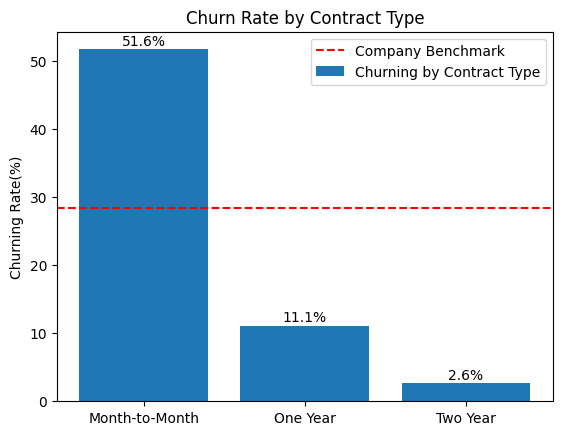

In [155]:
bars = plt.bar(churn_rate_contract.index, churn_rate_contract['churn_rate_by_contract'], label = 'Churning by Contract Type')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churning Rate(%)')
for bar in bars:
    width = bar.get_width()
    height = bar.get_height()
    plt.text(
        bar.get_x() + width/2, height + 0.6,
        f'{height:.1f}%', ha= 'center'
    )
plt.legend()

- Month-to-Month customers churn at 51.65%, nearly 5x times higher than Two-Year customers (23.25 percentage points above the company benchmark). Churn falls dramatically as contracts are strongly associated with customer retention. Since, Month-to-Month customers also represent the largest customer segment (3,146 customers), they account for the vast majority of churn risk.
- Customers on longer-term contracts exhibit substantially lower churn rats. While this does not prove causation, it indicates that contract commitment is a strong predictor of retention strategies.
- Regardless of conract type, competitor-related fators remain the leading driver of churn, indicating that competitive pressure persists even among customers with longer commitments.
- Given that over half of Month-to-Month customers churn, the company should prioritize converting Month-to-Month customers into annual contracts through targeted discounts, loyalty rewards, or bundled service packages.
- The Two-Year churn (2.62%) sits 25.78 percentage points below it. The Two-Year customers segment has very few churners (~48 customers), so category percentages shuld be interpreted cautiously because small sample can maplify percentage differences.


10. Do higher monthly charges correlate with churn?

In [156]:
churned_or_stayed_df['Monthly Charge'].value_counts().sort_index(ascending= False)

Monthly Charge
118.75    1
118.65    1
118.60    2
118.35    1
118.20    1
         ..
18.80     5
18.70     2
18.55     1
18.40     1
18.25     1
Name: count, Length: 1569, dtype: int64

In [157]:
churned_or_stayed_df['Monthly Charge'].describe()

count    6475.000000
mean       66.272008
std        29.917730
min        18.250000
25%        40.575000
50%        72.900000
75%        90.600000
max       118.750000
Name: Monthly Charge, dtype: float64

In [158]:
churned_or_stayed_df.groupby('Churned')['Monthly Charge'].agg(
    ['mean', 'median']
)

,mean,median
Churned,,
0,62.959362,66.40
1,74.622974,79.65


<Axes: xlabel='Churned', ylabel='Monthly Charge'>

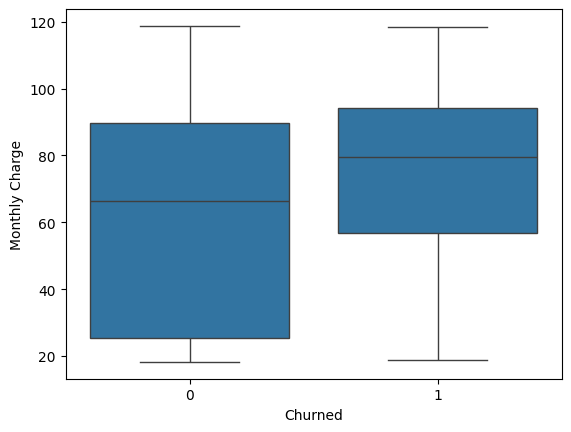

In [159]:
sns.boxplot(x='Churned', y = 'Monthly Charge', data= churned_or_stayed_df)

In [160]:
churned_or_stayed_df['Monthly Charge Quartile'] = pd.qcut(
    churned_or_stayed_df['Monthly Charge'], q = 4, labels = ['Q1\n ($18.25-40.55)', 'Q2\n ($40.60-72.90)', 'Q3\n ($72.95-90.60)', 'Q4\n ($90.65-118.75)']
)

In [161]:
churn_rate_monthly_charge_groups = round(churned_or_stayed_df.groupby('Monthly Charge Quartile')['Churned'].mean()*100,2)
churn_rate_monthly_charge_groups

Monthly Charge Quartile
Q1\n ($18.25-40.55)     13.34
Q2\n ($40.60-72.90)     28.01
Q3\n ($72.95-90.60)     38.81
Q4\n ($90.65-118.75)    33.46
Name: Churned, dtype: float64

In [162]:
churned_or_stayed_df.groupby('Monthly Charge Quartile', observed= True)['Monthly Charge'].agg(['min', 'max'])

,min,max
Monthly Charge Quartile,,
Q1\n ($18.25-40.55),18.25,40.55
Q2\n ($40.60-72.90),40.60,72.90
Q3\n ($72.95-90.60),72.95,90.60
Q4\n ($90.65-118.75),90.65,118.75


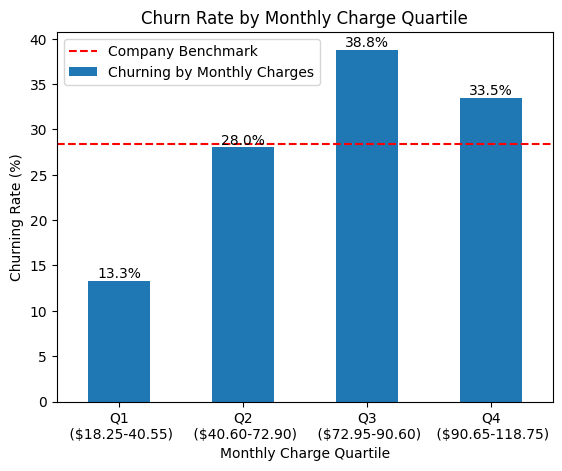

In [163]:
ax = churn_rate_monthly_charge_groups.plot(kind = 'bar', label = 'Churning by Monthly Charges')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Monthly Charge Quartile')
plt.legend()

In [164]:
churned_or_stayed_df.groupby('Monthly Charge Quartile')['Contract'].value_counts(normalize= True)*100

Monthly Charge Quartile  Contract      
Q1\n ($18.25-40.55)      Two Year          41.198271
                         Month-to-Month    34.156887
                         One Year          24.644842
Q2\n ($40.60-72.90)      Month-to-Month    56.199877
                         One Year          24.059223
                         Two Year          19.740901
Q3\n ($72.95-90.60)      Month-to-Month    60.444994
                         Two Year          23.053152
                         One Year          16.501854
Q4\n ($90.65-118.75)     Month-to-Month    43.537415
                         Two Year          29.189858
                         One Year          27.272727
Name: proportion, dtype: float64

In [165]:
churned_or_stayed_df.groupby('Monthly Charge Quartile')['Tenure in Months'].mean()

Monthly Charge Quartile
Q1\n ($18.25-40.55)     32.273626
Q2\n ($40.60-72.90)     28.901295
Q3\n ($72.95-90.60)     31.417182
Q4\n ($90.65-118.75)    45.654917
Name: Tenure in Months, dtype: float64

- To investigate the relationship between pricing and churn, monthly charges were first compared between churned and retained customers using a box plot. Churned customers exhibited a higher median monthly charge ($79.65) than retained customers ($66.40), indicating that customers paying more each month are generally more likely to leave. However, the distrbutions showed substantial overlap, suggesting that monthly charge alone does not clearly separate churners from non-churners. 
- Customers were divided into four equal-sized Monthly Charge Quartiles. The Monthly Charge Quartiles range are: Q1 ($18.25-40.55), Q2 ($40.60-72.90), Q3 ($72.95-90.60) and Q4 ($90.65-118.75) having churn rates as 13.34%, 28.01%, 38.81% and 33.46%.
- The results show that churn generally increases as monthly charges rise, but the relationship is not perfectly linear. Churn climbs from 13.34% in Q1 to a peak of 38.81% in Q3 before declining slightly to 33.46% in Q4. Q3 and Q4 are 10.41 and 5.06 percentage points above the company benchmark respectively, indicating that higher-paying customers are disproportionately represented among churners.
- The decline from Q3 to Q4 appears to be driven by differences in customer composition rather than pricing itself. Q3 contains the highest proportion of Month-to-Month customers (60.44%) , whereas Q4 contains a much larger share of One-Year and Two-Year contracts (56.46% combined versus 39.55% in Q3). In addition, Q4 customers have an average tenure of 45.65 months compared with roughly 29-31 months in Q2 and Q3. 
- Since, previous analysis showed that both long-term contracts and longer tenure are strongly associated with lower churn, these factors likely offset part of the churn risk associated with higher monthly charges.
- The company should prioritize retention efforts for customers in Q3 ($72.95-90.60/month), which represents the highest-risk segment with a churn rate of 38.81%. These customers generate relatively high monthly revenue but are heavily concentrated in Month-to-Month contracts.

11. Does subscribing to additional services like streaming, unlimited data, online security or device protection affect churn?

In [166]:
churned_or_stayed_df['Online Security Int'] = (churned_or_stayed_df['Online Security']=='Yes').astype(int)
churned_or_stayed_df['Online Backup Int'] = (churned_or_stayed_df['Online Backup']=='Yes').astype(int)
churned_or_stayed_df['Device Protection Plan Int'] = (churned_or_stayed_df['Device Protection Plan']=='Yes').astype(int)
churned_or_stayed_df['Premium Tech Support Int'] = (churned_or_stayed_df['Premium Tech Support']=='Yes').astype(int)
churned_or_stayed_df['Streaming TV Int'] = (churned_or_stayed_df['Streaming TV']=='Yes').astype(int)
churned_or_stayed_df['Streaming Movies Int'] = (churned_or_stayed_df['Streaming Movies']=='Yes').astype(int)
churned_or_stayed_df['Streaming Music Int'] = (churned_or_stayed_df['Streaming Music']=='Yes').astype(int)

In [167]:
services = ['Online Security Int', 'Online Backup Int', 'Device Protection Plan Int', 'Premium Tech Support Int', 'Streaming TV Int', 'Streaming Movies Int', 'Streaming Music Int']
for service in services:
    print(churned_or_stayed_df.groupby(service)['Churned'].mean()*100)

Online Security Int
0    34.112459
1    15.051546
Name: Churned, dtype: float64
Online Backup Int
0    31.843440
1    22.303082
Name: Churned, dtype: float64
Device Protection Plan Int
0    31.554693
1    22.874150
Name: Churned, dtype: float64
Premium Tech Support Int
0    33.894550
1    15.757267
Name: Churned, dtype: float64
Streaming TV Int
0    26.775531
1    30.798624
Name: Churned, dtype: float64
Streaming Movies Int
0    26.850886
1    30.655551
Name: Churned, dtype: float64
Streaming Music Int
0    27.468758
1    29.991646
Name: Churned, dtype: float64


In [168]:
pd.crosstab(churned_or_stayed_df['Internet Type'], churned_or_stayed_df['Streaming TV'], normalize='index')*100

Streaming TV,No,Yes
Internet Type,,
Cable,56.692913,43.307087
DSL,58.538206,41.461794
Fiber Optic,42.416898,57.583102
None,100.000000,0.000000


In [169]:
churned_or_stayed_df['Protective Services Count'] = (
    churned_or_stayed_df['Online Security Int'] + churned_or_stayed_df['Online Backup Int'] + churned_or_stayed_df['Device Protection Plan Int'] + churned_or_stayed_df['Premium Tech Support Int']
)
churned_or_stayed_df['Streaming Services Count'] = (
    churned_or_stayed_df['Streaming TV Int'] + churned_or_stayed_df['Streaming Movies Int'] + churned_or_stayed_df['Streaming Music Int']
)

In [170]:
churned_or_stayed_df.groupby('Protective Services Count')['Churned'].mean()*100

Protective Services Count
0    33.553174
1    41.381872
2    24.585219
3    12.758997
4     5.434783
Name: Churned, dtype: float64

In [171]:
churned_or_stayed_df.groupby('Protective Services Count')['Churned'].value_counts()

Protective Services Count  Churned
0                          0          1612
                           1           814
1                          0           789
                           1           557
2                          0          1000
                           1           326
3                          0           800
                           1           117
4                          0           435
                           1            25
Name: count, dtype: int64

In [172]:
churned_or_stayed_df.groupby('Streaming Services Count')['Churned'].mean()*100

Streaming Services Count
0    24.236388
1    37.136465
2    34.700315
3    27.626700
Name: Churned, dtype: float64

In [173]:
churned_or_stayed_df.groupby('Streaming Services Count')['Churned'].value_counts()

Streaming Services Count  Churned
0                         0          2282
                          1           730
1                         0           562
                          1           332
2                         0           621
                          1           330
3                         0          1171
                          1           447
Name: count, dtype: int64

In [174]:
protective_services_count_mean = churned_or_stayed_df[churned_or_stayed_df['Internet Type']!='None'].groupby('Protective Services Count')['Churned'].mean()*100
protective_services_count_mean

Protective Services Count
0    63.652803
1    41.381872
2    24.585219
3    12.758997
4     5.434783
Name: Churned, dtype: float64

In [175]:
streaming_services_count_mean = churned_or_stayed_df[churned_or_stayed_df['Internet Type']!='None'].groupby('Streaming Services Count')['Churned'].mean()*100
streaming_services_count_mean

Streaming Services Count
0    36.643026
1    37.136465
2    34.700315
3    27.626700
Name: Churned, dtype: float64

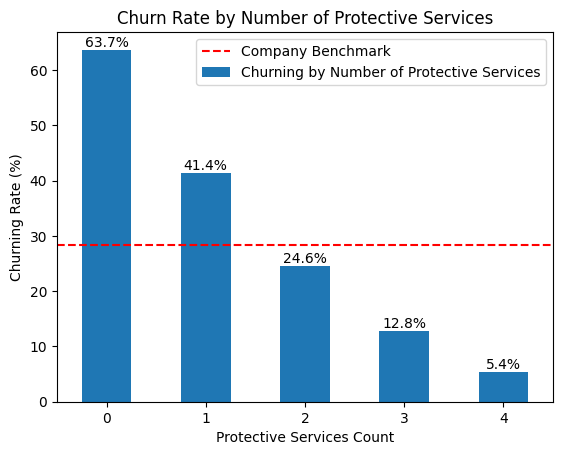

In [176]:
ax = protective_services_count_mean.plot(kind = 'bar', label = 'Churning by Number of Protective Services')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Number of Protective Services')
plt.legend()

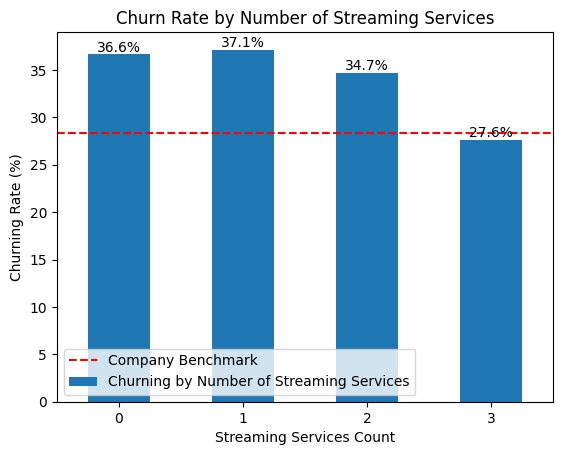

In [177]:
ax = streaming_services_count_mean.plot(kind = 'bar', label = 'Churning by Number of Streaming Services')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Number of Streaming Services')
plt.legend()

A. Protective Services Show a Strong Churn-Reducing Effect
- To better understand the impact of value-added services, four protection-oriented services were grouped into a Protective Services Count metric: Online Security, Online Backup, Device Protection and Premium Tech Support. Since customers without internet service cannot subscribe to these services, customers with Internet Type = None were excluded from this analysis.
- The churn rate for customers using 0, 1, 2, 3 and 4 number of services are 63.65%, 41.38%, 24.59%, 12.76% and 5.43%. A clear monotonic decline is observed: churn falls consistently as customers adopt more protective services. Customers with zero protective services churn at 63.65%, which is 35.25 percentage points above the company-wide benchmark while those with all four services churn at 5.43%, 22.97 percentage points below it.
- Key percentage-point reductions include:
0 → 1 services: -22.27 pp
1 → 2 services: -16.80 pp
2 → 3 services: -11.83 pp
3 → 4 services: -7.33 pp
Overall (0 → 4 services): -58.22 percentage points
Customers with all four protective services churn at only 5.43%, compared with 63.65% among customers with none. This makes protective services one of the strongest retention indicators identified in the entire analysis.
- Business Insight: Protective services increase customer dependence on the provider and create additional switching costs, making customers significantly less likely to leave.


B. Streaming Services Initially Appeared Risky, but the Relationship Was Misleading
- A separate Streaming Services Count metric was created using: Streaming TV, Streaming Movies and Streaming Music.
- Initial service-level analysis suggested that streaming subscribers churned more frequently. However, further investigation revealed that streaming adoption overlaps heavily with Fiber Optic customers, the internet segment previously identified as having the highest churn rate.
- After accounting for this Internet Type confounding effect, the churn pattern for streaming services for customers using 0, 1, 2, and 3 number of services are 36.64%, 37.14%, 4.70% and 27.63%.
- The relationship is neither monotonic nor consistently increasing. In fact, customers subscribed to all three streaming services exhibit lower churn than customers with only one or two streaming services.
- Business Insight: Streaming services do not appear to have a strong standalone effect on churn. The earlier apparent relationship was largely influenced by the higher churn propensity of Fiber Optic customers, who are more likely to subscribe to streaming services.


- Protective services represent a clear and actionable retention lever. The company should actively bundle and promote: Online Security, Online Backup, Device Protection and Premium Tech Support
- Retention campaigns should prioritize the high-risk customer segments identified earlier in the analysis: Month-to-Month contract customers, Q3 Monthly Charge customers (highest churn quartile) and Fiber Optic customers.
- Increasing adoption of protective services within these segments could substantially reduce churn while simultaneously increasing customer engagement and perceived service value.

12. Does payment method affect churn?

In [178]:
churn_rate_payment_method = (churned_or_stayed_df.groupby('Payment Method')['Churned'].mean()*100).sort_values(ascending = False)
churn_rate_payment_method

Payment Method
Mailed Check       41.246291
Bank Withdrawal    35.731807
Credit Card        15.755367
Name: Churned, dtype: float64

In [179]:
churned_or_stayed_df['Payment Method'].value_counts()

Payment Method
Bank Withdrawal    3669
Credit Card        2469
Mailed Check        337
Name: count, dtype: int64

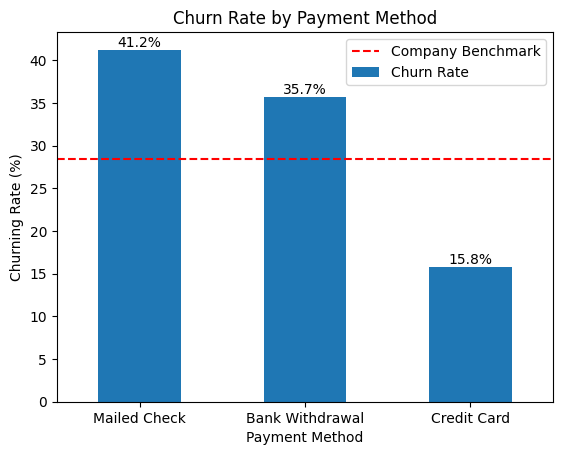

In [180]:
ax = churn_rate_payment_method.plot(kind = 'bar', label = 'Churn Rate')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.legend()

- Credit Card customers exhibit the lowest churn rate (15.76%), whie Mailed Check customers have the highest churn rate (41.25%), creating a substantial 25.49 percentage point gap. However, this relationship may be influenced by customer characteristics rather than payment method alone. Credit Card users are ikely to be more digitally engaged, enrolled in auto-pay and potentially on longer-term contracts. A quick validation would be to compare payment methods against contract typ and tenure distributions.
- Mailed Check customers have the highest churn rate (41.25%), but this segment contains only 337 customers(5.2% of the customer base). While the sample size is smaller than other payment methods, it remains large enough to provide a reasonably reliable estimate and exceeds the minimum thresholds typically used in this analysis.
- Bank Withdrawl customers churn at 35.73%, which is 7.33 percentage points above the company benchmark (28.4%). Since this group contains 3,669 customers (56.8% of all customers), the finding is highly reliable and has greater business significance than the Mailed Check segment due to its much larger customer base.
- Payment method is strongly associated wit churn, with Credit Card customers showing substantially better retention than customers using Bank Withdrawal or Mailed Check. However, payment method may act as a proxy for underlying customer characteristics such as contract type, tenure and level of engagement. Further analysis is required to determine whether payment method itself drives churn or simply reflects differences in customer profiles.
- The company should investigate the characteristics of low-churn Credit Card customers and evaluate opportunities to encourage adoption of automated payment methods. Additionally, cross-analysis with contract type and tenure should be performed before attributing churn differences directly to payment method.

13. Does number of referral affect churn?

In [181]:
churned_or_stayed_df['Number of Referrals'].value_counts()

Number of Referrals
0     3386
1     1053
5      251
3      245
7      240
4      230
2      224
9      218
10     212
6      211
8      204
11       1
Name: count, dtype: int64

In [182]:
(churned_or_stayed_df.groupby('Number of Referrals')['Churned'].mean()*100).sort_values(ascending= False)

Number of Referrals
1     47.483381
0     36.148848
3     13.061224
2     11.607143
5      7.968127
4      7.391304
6      3.791469
7      2.500000
9      1.834862
8      0.980392
10     0.000000
11     0.000000
Name: Churned, dtype: float64

In [183]:
(churned_or_stayed_df.groupby('Number of Referrals')['Tenure in Months'].mean()).sort_values(ascending= False)

Number of Referrals
11    72.000000
9     49.903670
10    47.820755
7     47.812500
5     47.760956
4     46.604348
2     46.397321
8     45.235294
6     44.829384
3     42.897959
1     36.567901
0     26.695216
Name: Tenure in Months, dtype: float64

In [184]:
pd.crosstab(churned_or_stayed_df['Number of Referrals'], churned_or_stayed_df['Contract'])

Contract,Month-to-Month,One Year,Two Year
Number of Referrals,,,
0,2045,688,653
1,545,246,262
2,57,73,94
3,89,64,92
4,75,46,109
5,59,71,121
6,68,62,81
7,53,85,102
8,54,51,99


In [185]:
bins = [-1, 0, 1, 3, 5, 10]
labels = ['0', '1', '2-3', '4-5', '6-10']
churned_or_stayed_df['Referral Group'] = pd.cut(churned_or_stayed_df['Number of Referrals'], bins = bins, labels = labels)
churn_rate_referral_grp = churned_or_stayed_df.groupby('Referral Group')['Churned'].mean()*100

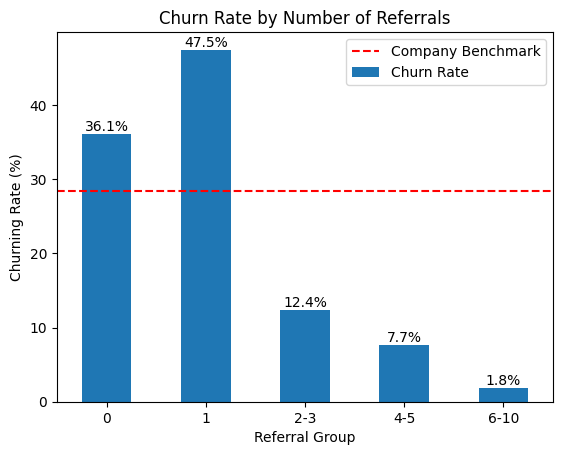

In [186]:
ax = churn_rate_referral_grp.plot(kind = 'bar', label = 'Churn Rate')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Number of Referrals')
plt.legend()

- Referral activity exhibits a strong relationship with churn, but the pattern is not strictly linear. Customers with no referrals have a churn rate of 36.15%, while customers with exactly one referral exhibit the highest churn rate at 47.48%. After this initial spike, churn declines sharply as referral counts increase, falling to approximately 12–13% for customers with 2–3 referrals, 7–8% for customers with 4–5 referrals, and below 4% for customers with 6 or more referrals.

- The most notable finding is the unusually high churn rate among customers with exactly one referral. This group experiences greater churn than customers with no referrals, indicating that the relationship between referrals and churn is more complex than a simple "more referrals = lower churn" pattern.

- Further investigation suggests that referral count is strongly associated with customer tenure and contract commitment. Customers with higher referral counts have substantially longer average tenure, generally ranging from 44 to 49 months, compared with 26.7 months for customers with no referrals. They are also more likely to be on One-Year and Two-Year contracts, both of which are associated with lower churn.

- However, tenure and contract type do not fully explain the one-referral spike. Customers with exactly one referral have an average tenure of 36.6 months and a more favorable contract mix than customers with no referrals, yet they still exhibit the highest churn rate. This suggests that the one-referral segment may represent a distinct customer group that warrants further investigation.

- Overall, customers who make multiple referrals appear to be among the company's most loyal and engaged customers. While referrals themselves may not directly reduce churn, sustained referral activity serves as a strong indicator of customer satisfaction, long-term engagement, and retention.

14. Do demographic factors like gender, marital status and number of dependents affect churn?

In [187]:
churned_or_stayed_df.groupby('Gender')['Churned'].mean()*100

Gender
Female    28.553732
Male      28.250154
Name: Churned, dtype: float64

In [188]:
churn_rate_married = churned_or_stayed_df.groupby('Married')['Churned'].mean()*100
churn_rate_married

Married
No     36.717533
Yes    20.220588
Name: Churned, dtype: float64

In [189]:
churned_or_stayed_df.groupby('Number of Dependents')['Churned'].mean()*100

Number of Dependents
0    35.002019
1     7.335907
2     6.412826
3     6.224066
4    16.666667
5    22.222222
6    33.333333
7    50.000000
8     0.000000
9     0.000000
Name: Churned, dtype: float64

In [190]:
churned_or_stayed_df['Number of Dependents'].value_counts()

Number of Dependents
0    4954
1     518
2     499
3     482
5       9
4       6
6       3
7       2
9       1
8       1
Name: count, dtype: int64

In [191]:
pd.crosstab(churned_or_stayed_df['Married'], churned_or_stayed_df['Number of Dependents']>0, normalize = 'index')*100

Number of Dependents,False,True
Married,,
No,91.996263,8.003737
Yes,61.274510,38.725490


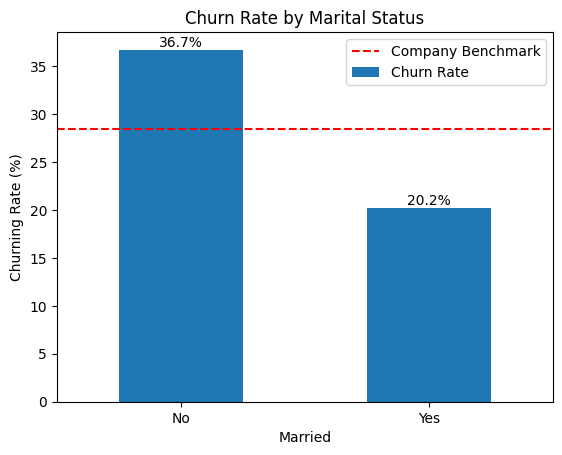

In [192]:
ax = churn_rate_married.plot(kind = 'bar', label = 'Churn Rate')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Marital Status')
plt.legend()

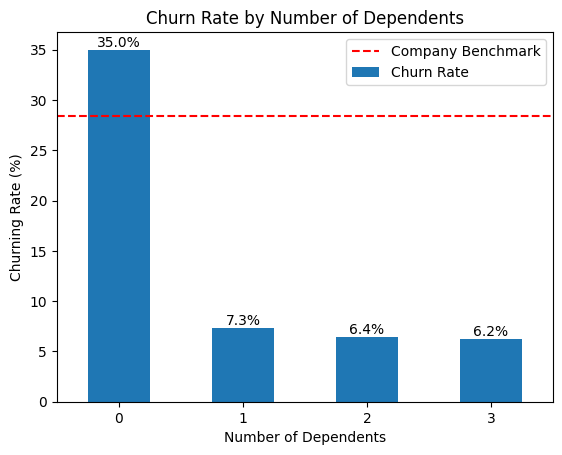

In [193]:
churn_rate_dependents = churned_or_stayed_df[churned_or_stayed_df['Number of Dependents']<4].groupby('Number of Dependents')['Churned'].mean()*100
ax = churn_rate_dependents.plot(kind = 'bar', label = 'Churn Rate')
plt.axhline(y=28.4, color = 'red', linestyle = '--', label = 'Company Benchmark')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.1f%%')
plt.ylabel('Churning Rate (%)')
plt.title('Churn Rate by Number of Dependents')
plt.legend()

- Gender has virtually no impact on customer churn. Female customers exhibit a churn rate of 28.55%, while male customers show a nearly identical churn rate of 28.25%, a negligible difference of just 0.30 percentage points.
This indicates that churn behavior is consistent across genders, suggesting that gender is not a meaningful predictor of customer attrition and should not be a primary focus for retention initiatives.
- Marital status shows a much stronger relationship with churn. Customers who are not married have a churn rate of 36.72%, which is 8.32 percentage points above the company-wide benchmark while married cutsomers churn at 20.22%, which is 8.18 percentage points below it.
This represents a substantial 16.50 percentage point reduction in churn among married customers. The result suggests that married customers may have more stable service requirements, longer-term commitments, or greater reliance on household communication services, making them significantly less likely to leave.
- The number of dependents also exhibits a strong association with churn. Customers with no dependents experience a churn rate of 35.00%, considerably higher than the overall churn benchmark of 28.4%. In contrast, customers with one to three dependents show exceptionally low churn rates ranging from 6.22% to 7.34%, indicating significantly stronger customer loyalty and retention. While churn rates appear to increase again for customers with four or more dependents, these categories contain very few observations (fewer than 10 customers each) and therefore do not provide reliable evidence for meaningful conclusions.
- Further analysis shows that marital status and dependents are related but not identical factors. Approximately 92% of unmarried customers have no dependents, while 39% of married customers have at least one dependent. This indicates that both variables capture different aspects of household structure and can independently contribute to explaining customer retention behavior.
- Among the demographic factors analyzed, gender has virtually no effect on churn, whereas marital status and the presence of dependents are strongly associated with customer retention. Customers who are married and those with dependents exhibit substantially lower churn rates, suggesting that greater household stability and family commitments are linked to stronger customer loyalty. These findings indicate that family-oriented households represent a relatively stable customer segment, while unmarried customers and those without dependents may require greater retention attention due to their significantly higher propensity to churn.
- Retention campaigns should prioritize customers who are unmarried and have no dependents, as these groups exhibit the highest churn rates. Conversely, married customers and customers with dependents already demonstrate strong retention and may require less intensive intervention. Understanding the needs and motivations of customers with weaker household ties could help the company design more effective churn-reduction strategies.

In [194]:
churned_or_stayed_df[['Monthly Charge', 'Tenure in Months', 'Total Charges']]

,Monthly Charge,Tenure in Months,Total Charges
0,65.60,9,593.30
1,73.90,4,280.85
2,98.00,13,1237.85
3,83.90,3,267.40
4,69.40,9,571.45
...,...,...,...
6917,20.95,4,85.50
6918,55.15,13,742.90
6919,85.10,22,1873.70
6921,67.85,67,4627.65


In [195]:
import os
os.getcwd()

'c:\\Users\\Arpita\\Desktop\\Customer Churn Prediction\\notebooks'

In [ ]:
churned_or_stayed_df.to_csv("churned_or_stayed_df.csv", index = False)

In [197]:
churned_or_stayed_df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason',
       'Age Groups', 'Churned', 'Churned Senior', 'Tenure Groups in Months',
       'Churned Early Tenure', 'Monthly Charge Quartile',
       'Online Security Int', 'Online Backup Int',
       'Device Protection Plan Int', 'Premium 

In [198]:
churned_or_stayed_df.info()

<class 'pandas.DataFrame'>
Index: 6475 entries, 0 to 6922
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        6475 non-null   str     
 1   Gender                             6475 non-null   str     
 2   Age                                6475 non-null   int64   
 3   Married                            6475 non-null   str     
 4   Number of Dependents               6475 non-null   int64   
 5   City                               6475 non-null   str     
 6   Zip Code                           6475 non-null   int64   
 7   Latitude                           6475 non-null   float64 
 8   Longitude                          6475 non-null   float64 
 9   Number of Referrals                6475 non-null   int64   
 10  Tenure in Months                   6475 non-null   int64   
 11  Offer                              6475 non-null   str     

In [199]:
churned_or_stayed_df['Monthly Charge'].median()

np.float64(72.9)

In [200]:
churned_or_stayed_df[churned_or_stayed_df['Churned']==1]['Tenure in Months'].mean()

np.float64(18.11310494834149)